In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# TFM - Predicción del margen necesario de tierra vegetal
## 1. Análisis Exploratorio de Datos (EDA)

Dataset sintético: `dataset_jardineria_tierra_sucio.csv`.
Cada fila representa una obra de jardinería terminada.

In [23]:
df_sucio = pd.read_csv("dataset_jardineria_tierra_sucio.csv")
df = df_sucio.copy()
df_sucio.head(10)



,obra_id,superficie_m2,tipo_trabajo,espesor_cm,densidad_suelo,tierra_teorica_kg,tipo_suelo,pendiente_pct,nivelacion,accesibilidad,operarios,experiencia_operarios,lluvia_previa_mm,estacion,tierra_pedida_kg,tierra_sobrante_kg,tierra_consumida_real_kg,margen_necesario_pct
0,1,251.000,renovacion,7.9,1262.8,25040.06,arcilloso,4.3,5.0,5.0,3.0,4.5,1.5,otoño,27476.07,240.00,27236.07,8.77
1,2,340.200,ampliacion,9.9,1446.9,48731.30,arenoso,9.5,4.0,3.0,NaN,3.7,4.1,verano,48415.81,0.00,50807.25,4.26
2,3,NaN,instalacion,4.1,1259.5,11386.51,arcilloso,7.7,5.0,3.0,4.0,7.3,1.7,primavera,11298.40,NaN,11516.32,1.14
3,4,197.400,instalacion,3.6,1415.0,10055.56,NaN,0.9,3.0,NaN,5.0,4.7,8.8,verano,10869.00,124.63,10744.37,6.85
4,5,369.500,ampliacion,7.7,1428.0,40628.74,mixto,5.1,5.0,2.0,5.0,13.9,12.8,verano,40696.71,0.00,40803.44,0.43
5,6,210.400,renovacion,5.4,1372.5,15593.80,arcilloso,1.3,4.0,5.0,5.0,4.7,1.2,invierno,16242.27,0.00,16428.07,5.35
6,7,281.500,renovacion,3.5,1458.9,14373.81,arcilloso,3.1,4.0,3.0,4.0,6.5,7.1,verano,14442.90,0.00,14955.95,4.05
7,8,13.135,ampliacion,6.3,1287.3,21304.94,arcilloso,1.1,1.0,5.0,NaN,8.0,27.1,invierno,23419.66,0.00,23433.30,9.99
8,9,369.300,renovacion,8.3,1464.5,44889.71,mixto,1.2,3.0,3.0,2.0,1.7,34.0,verano,48046.80,504.11,47542.69,5.91
9,10,172.700,instalacion,5.0,1418.8,12251.34,NaN,6.7,4.0,3.0,1.0,3.9,21.3,invierno,12368.64,0.00,12398.36,1.20


## 1.1 Dimensiones y tipos de datos

In [24]:
print(f"Shape: {df.shape}")
print(df.dtypes)

Shape: (659, 18)
obra_id                       int64
superficie_m2               float64
tipo_trabajo                    str
espesor_cm                  float64
densidad_suelo              float64
tierra_teorica_kg           float64
tipo_suelo                      str
pendiente_pct               float64
nivelacion                  float64
accesibilidad               float64
operarios                   float64
experiencia_operarios       float64
lluvia_previa_mm            float64
estacion                        str
tierra_pedida_kg            float64
tierra_sobrante_kg          float64
tierra_consumida_real_kg    float64
margen_necesario_pct        float64
dtype: object


## 1.2 Valores nulos por columna

In [25]:
nulls = df.isna().sum()
pct = (nulls / len(df) * 100).round(2)
pd.DataFrame({'nulos': nulls, 'pct': pct})

,nulos,pct
obra_id,0,0.00
superficie_m2,22,3.34
tipo_trabajo,0,0.00
espesor_cm,23,3.49
densidad_suelo,23,3.49
tierra_teorica_kg,0,0.00
tipo_suelo,25,3.79
pendiente_pct,26,3.95
nivelacion,19,2.88
accesibilidad,23,3.49


## 1.3 Duplicados

In [26]:
print(f"Duplicados exactos (incl. obra_id): {df.duplicated().sum()}")
 
cols_no_id = [c for c in df.columns if c != 'obra_id']
print(f"Duplicados ignorando obra_id: {df.duplicated(subset=cols_no_id).sum()}")

Duplicados exactos (incl. obra_id): 0
Duplicados ignorando obra_id: 3


## 1.4 Variables categóricas: detección de errores tipográficos / inconsistencias

In [27]:
for col in ['tipo_trabajo', 'tipo_suelo', 'estacion']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- tipo_trabajo ---
tipo_trabajo
instalacion     288
renovacion      219
ampliacion      143
Renovacion        3
renovaci0n        2
Instalacion       2
Ampliacion        1
instalacion       1
Name: count, dtype: int64

--- tipo_suelo ---
tipo_suelo
mixto         225
arenoso       215
arcilloso     186
NaN            25
Arenoso         5
arcilloso       2
mxto            1
Name: count, dtype: int64

--- estacion ---
estacion
otoño         175
primavera     172
verano        160
invierno      118
NaN            25
primavera       3
Verano          1
Otoño           1
inviernoo       1
invierno        1
otoño           1
Primavera       1
Name: count, dtype: int64


## 1.5 Estadísticas descriptivas (variables numéricas)

Buscamos outliers e inconsistencias de rango (p.ej. nivelacion fuera de 1-5, accesibilidad=0, lluvia negativa, superficie/lluvia desproporcionadas).

In [28]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('obra_id')
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
superficie_m2,637.0,240.915322,214.354799,4.0250,119.200,201.00,313.4000,3721.00
espesor_cm,636.0,6.448899,2.035267,3.0000,4.700,6.50,8.3000,10.00
densidad_suelo,636.0,1346.846698,87.296483,1200.2000,1267.850,1345.05,1420.6000,1499.80
tierra_teorica_kg,659.0,20849.003016,20242.131854,578.3075,8573.275,16286.17,27186.9300,327826.24
pendiente_pct,633.0,5.749605,4.725396,0.0000,2.300,4.50,7.6000,25.00
nivelacion,640.0,2.975000,1.416204,1.0000,2.000,3.00,4.0000,6.00
accesibilidad,636.0,3.056604,1.407495,0.0000,2.000,3.00,4.0000,5.00
operarios,629.0,3.365660,1.709797,1.0000,2.000,3.00,5.0000,6.00
experiencia_operarios,636.0,7.238522,4.642414,0.2000,3.900,6.00,9.8250,20.00
lluvia_previa_mm,636.0,14.140943,18.592825,-27.9000,4.500,10.00,19.2000,322.40


## 1.6 Distribución de la variable objetivo: `margen_necesario_pct`

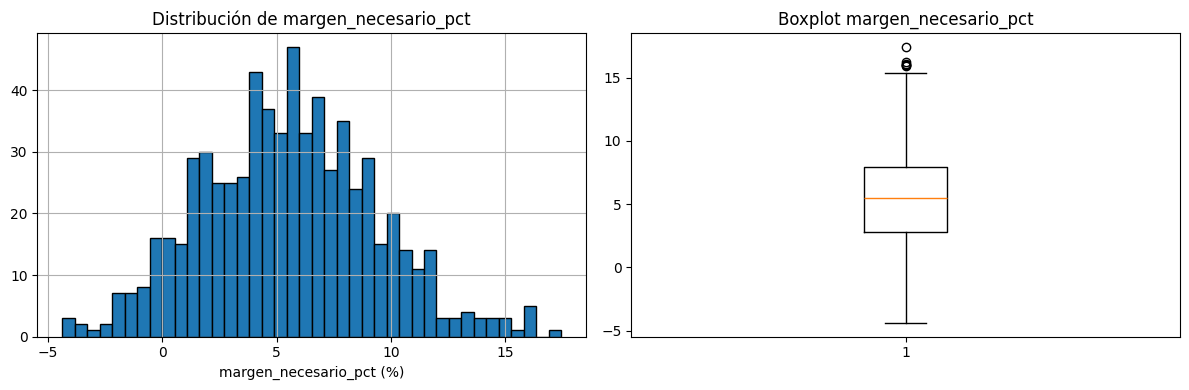

count    659.000000
mean       5.501684
std        3.779743
min       -4.380000
25%        2.790000
50%        5.500000
75%        7.950000
max       17.450000
Name: margen_necesario_pct, dtype: float64

Asimetría (skew): 0.19443152955618098


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
df['margen_necesario_pct'].hist(bins=40, ax=axes[0], edgecolor='black')
axes[0].set_title('Distribución de margen_necesario_pct')
axes[0].set_xlabel('margen_necesario_pct (%)')
 
axes[1].boxplot(df['margen_necesario_pct'].dropna())
axes[1].set_title('Boxplot margen_necesario_pct')
 
plt.tight_layout()
plt.show()
 
print(df['margen_necesario_pct'].describe())
print("\nAsimetría (skew):", df['margen_necesario_pct'].skew())

## 1.7 Relaciones feature-target (validación de las reglas de negocio)

Comprobamos visualmente las relaciones no lineales diseñadas:
- Pendiente: incremento acelerado a partir de 10%
- Nivelación: a mejor nivelación, menor margen
- Experiencia: mejora con saturación a partir de 10 años
- Lluvia x tipo de suelo: mayor impacto en suelo arcilloso (efecto cruzado)

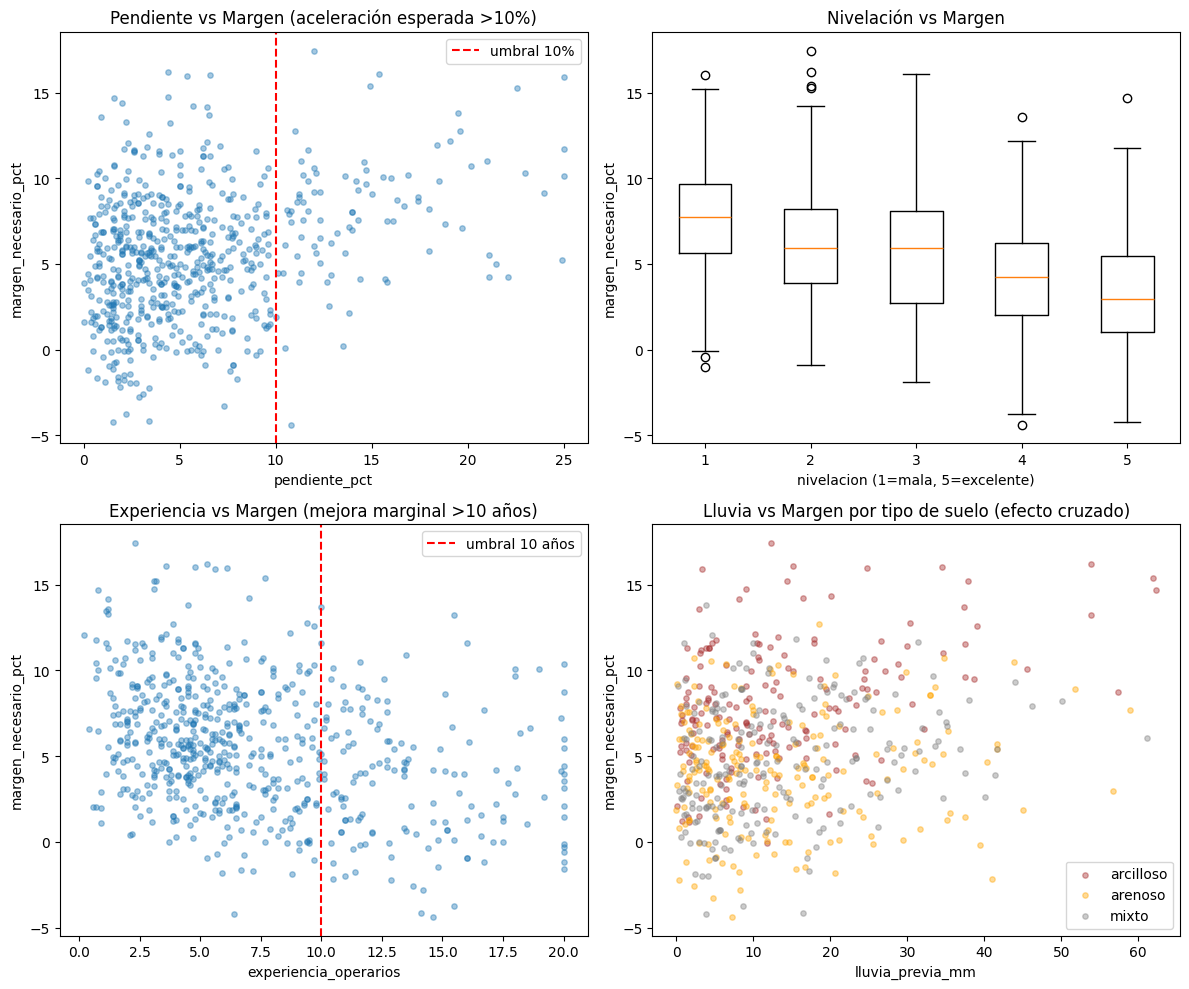

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
 
# --- Pendiente vs margen ---
axes[0, 0].scatter(df['pendiente_pct'], df['margen_necesario_pct'], alpha=0.4, s=15)
axes[0, 0].axvline(10, color='red', linestyle='--', label='umbral 10%')
axes[0, 0].set_xlabel('pendiente_pct')
axes[0, 0].set_ylabel('margen_necesario_pct')
axes[0, 0].set_title('Pendiente vs Margen (aceleración esperada >10%)')
axes[0, 0].legend()
 
# --- Nivelación vs margen (boxplot por categoría) ---
df_niv = df.dropna(subset=['nivelacion', 'margen_necesario_pct'])
df_niv = df_niv[df_niv['nivelacion'].between(1, 5)]  # excluir inconsistencia (6)
niveles = sorted(df_niv['nivelacion'].unique().astype(int))
groups = [df_niv[df_niv['nivelacion'] == v]['margen_necesario_pct'] for v in niveles]
axes[0, 1].boxplot(groups, tick_labels=niveles)
axes[0, 1].set_xlabel('nivelacion (1=mala, 5=excelente)')
axes[0, 1].set_ylabel('margen_necesario_pct')
axes[0, 1].set_title('Nivelación vs Margen')
 
# --- Experiencia vs margen ---
axes[1, 0].scatter(df['experiencia_operarios'], df['margen_necesario_pct'], alpha=0.4, s=15)
axes[1, 0].axvline(10, color='red', linestyle='--', label='umbral 10 años')
axes[1, 0].set_xlabel('experiencia_operarios')
axes[1, 0].set_ylabel('margen_necesario_pct')
axes[1, 0].set_title('Experiencia vs Margen (mejora marginal >10 años)')
axes[1, 0].legend()
 
# --- Lluvia vs margen, por tipo de suelo (efecto cruzado) ---
df_lluvia = df[(df['lluvia_previa_mm'] >= 0) & (df['lluvia_previa_mm'] <= 100)]
for suelo, color in [('arcilloso', 'brown'), ('arenoso', 'orange'), ('mixto', 'gray')]:
    sub = df_lluvia[df_lluvia['tipo_suelo'] == suelo]
    axes[1, 1].scatter(sub['lluvia_previa_mm'], sub['margen_necesario_pct'],
                        alpha=0.4, s=15, label=suelo, color=color)
axes[1, 1].set_xlabel('lluvia_previa_mm')
axes[1, 1].set_ylabel('margen_necesario_pct')
axes[1, 1].set_title('Lluvia vs Margen por tipo de suelo (efecto cruzado)')
axes[1, 1].legend()
 
plt.tight_layout()
plt.show()

## 1.8 Matriz de correlación (variables permitidas + target)

Excluimos las columnas de leakage (`tierra_pedida_kg`, `tierra_sobrante_kg`, `tierra_consumida_real_kg`) y `obra_id`.

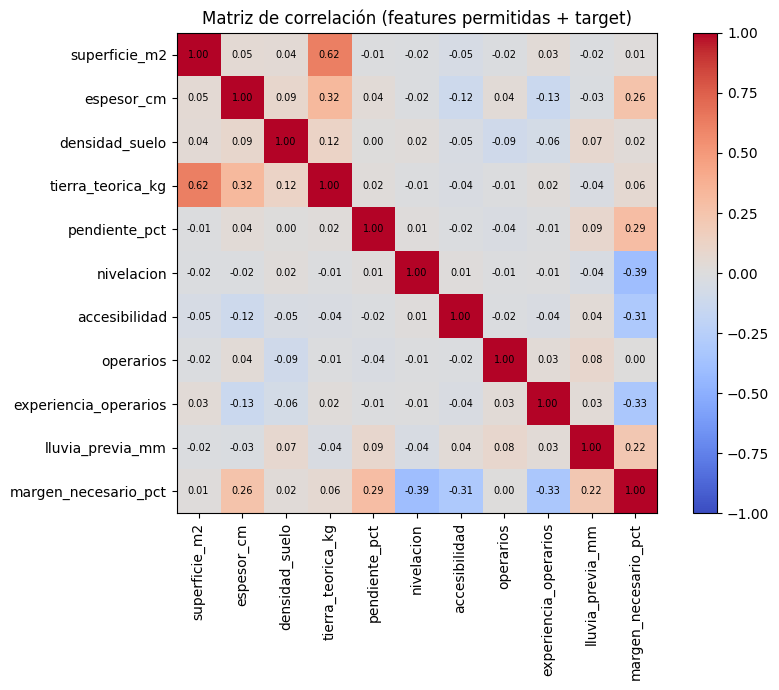

Correlaciones con margen_necesario_pct:
margen_necesario_pct     1.000000
pendiente_pct            0.293968
espesor_cm               0.256876
lluvia_previa_mm         0.219566
tierra_teorica_kg        0.059859
densidad_suelo           0.024109
superficie_m2            0.014885
operarios                0.002880
accesibilidad           -0.307987
experiencia_operarios   -0.325878
nivelacion              -0.394261
Name: margen_necesario_pct, dtype: float64


In [31]:
leakage_cols = ['tierra_pedida_kg', 'tierra_sobrante_kg', 'tierra_consumida_real_kg']
cols_corr = [c for c in df.select_dtypes(include=[np.number]).columns
             if c not in leakage_cols + ['obra_id']]
 
corr = df[cols_corr].corr()
 
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(cols_corr)))
ax.set_yticks(range(len(cols_corr)))
ax.set_xticklabels(cols_corr, rotation=90)
ax.set_yticklabels(cols_corr)
for i in range(len(cols_corr)):
    for j in range(len(cols_corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=7)
plt.colorbar(im)
plt.title('Matriz de correlación (features permitidas + target)')
plt.tight_layout()
plt.show()
 
print("Correlaciones con margen_necesario_pct:")
print(corr['margen_necesario_pct'].sort_values(ascending=False))

## 1.9 Resumen de hallazgos del EDA

- **Tamaño**: 659 filas (650 obras + ~1.5% duplicados intencionales).
- **Nulos**: entre el 2.9% y el 4.6% en casi todas las features; el target no tiene nulos.
- **Categóricas**: errores tipográficos confirmados en `tipo_trabajo`, `tipo_suelo` y `estacion` (mayúsculas, espacios extra, tildes mal escritas).
- **Outliers**: presentes en `superficie_m2`, `tierra_teorica_kg`, `lluvia_previa_mm` y `tierra_pedida_kg` (factores ~x5/x8/x0.05).
- **Inconsistencias de rango**: `nivelacion`=6 (fuera de 1-5), `accesibilidad`=0 (fuera de 1-5), `lluvia_previa_mm` negativa.
- **Target (`margen_necesario_pct`)**: distribución casi simétrica (skew≈0.19), rango aproximado [-4.4, 17.45], media≈5.5%.
- **Relaciones con el target**: correlaciones moderadas y en la dirección esperada según las reglas de negocio:
    - Negativas: `nivelacion` (-0.39), `experiencia_operarios` (-0.33), `accesibilidad` (-0.31)
    - Positivas: `pendiente_pct` (+0.29), `espesor_cm` (+0.26), `lluvia_previa_mm` (+0.22)
    - Prácticamente nulas (esperado): `operarios`, `superficie_m2`, `densidad_suelo`
- `tierra_teorica_kg` correlaciona fuertemente con `superficie_m2` (0.62) y moderadamente con `espesor_cm` (0.32) -> confirma que NO debe usarse junto con sus componentes (multicolinealidad).

Las relaciones bivariadas muestran tendencias coherentes con las hipótesis de negocio, aunque con solapamiento considerable debido a efectos de múltiples variables interactuando y al ruido introducido. Se espera que un modelo multivariante (especialmente basado en árboles) capture mejor estas relaciones no lineales y cruzadas.

## 2. Limpieza de datos

### Estrategia acordada:

| Problema | Tratamiento |
|---|---|
| Duplicados | Eliminados (ignorando `obra_id`) |
| Errores tipográficos en categóricas | Normalizar (lower + strip) y mapear variantes |
| `nivelacion`, `accesibilidad` fuera de rango [1,5] | Clip a [1, 5] (corrección de error de entrada) |
| `lluvia_previa_mm` negativa | Clip a [0, ∞) (corrección de imposible físico) |
| Outliers "altos pero posibles" (`superficie_m2`, `tierra_teorica_kg`, `lluvia_previa_mm`, `tierra_pedida_kg`) | **NO se tocan** |
| Nulos (todas las columnas, ~3-4% cada una) | **NO se imputan**, se dejan como NaN |

### Justificación de las decisiones clave

**Outliers altos:** son valores físicamente posibles (aunque atípicos), no errores de entrada. Recortarlos por percentiles es una decisión estadística que puede romper relaciones de coherencia entre columnas (p.ej. `tierra_teorica_kg` vs `superficie_m2`, o `tierra_sobrante_kg` vs `tierra_pedida_kg`). Dado que el modelo elegido (basado en árboles, ver siguiente punto) es robusto a estos pocos valores extremos, se conservan tal cual.

**Nulos:** con un porcentaje bajo (2.9%-4.6% por columna) y dado que de todos modos necesitamos un modelo que soporte NaN de forma nativa (`HistGradientBoostingRegressor`, XGBoost o LightGBM, porque `superficie_m2`, `espesor_cm` y `densidad_suelo` no pueden imputarse sin comprometer la coherencia de `tierra_teorica_kg`), se opta por dejar TODOS los nulos como NaN y que sea el propio algoritmo quien decida cómo manejarlos en cada split. Esto evita introducir sesgos de imputación arbitrarios (mediana/moda) y simplifica el pipeline.

### 2.1 Eliminación de duplicados

In [32]:
cols_no_id = [c for c in df.columns if c != 'obra_id']
n_dup = df.duplicated(subset=cols_no_id).sum()
df = df.drop_duplicates(subset=cols_no_id).reset_index(drop=True)
print(f"Duplicados eliminados: {n_dup}")
print("Shape:", df.shape)

Duplicados eliminados: 3
Shape: (656, 18)


### 2.2 Normalización de variables categóricas

Pasamos a minúsculas, eliminamos espacios sobrantes y mapeamos los errores tipográficos detectados en el EDA (tildes mal escritas, letras omitidas).

In [33]:
typo_fix = {
    'renovaci0n': 'renovacion',
    'arciloso': 'arcilloso',
    'mxto': 'mixto',
    'inviernoo': 'invierno',
    'arnoso': 'arenoso',
}
 
cat_cols = ['tipo_trabajo', 'tipo_suelo', 'estacion']
for col in cat_cols:
    df[col] = df[col].apply(lambda v: str(v).strip().lower() if pd.notna(v) else v)
    df[col] = df[col].replace(typo_fix)
 
for col in cat_cols:
    print(f"{col}: {sorted(df[col].dropna().unique())}")

tipo_trabajo: ['ampliacion', 'instalacion', 'renovacion']
tipo_suelo: ['arcilloso', 'arenoso', 'mixto']
estacion: ['invierno', 'otoño', 'primavera', 'verano']


### 2.3 Corrección de inconsistencias de rango

`nivelacion` y `accesibilidad` deben estar en [1, 5]; `lluvia_previa_mm` no puede ser negativa.

In [34]:
print("Antes:")
print(f"  nivelacion fuera de [1,5]: {((df.nivelacion < 1) | (df.nivelacion > 5)).sum()}")
print(f"  accesibilidad fuera de [1,5]: {((df.accesibilidad < 1) | (df.accesibilidad > 5)).sum()}")
print(f"  lluvia_previa_mm < 0: {(df.lluvia_previa_mm < 0).sum()}")
 
df['nivelacion'] = df['nivelacion'].clip(1, 5)
df['accesibilidad'] = df['accesibilidad'].clip(1, 5)
df['lluvia_previa_mm'] = df['lluvia_previa_mm'].clip(0, None)
 
print("\nDespués: 0 inconsistencias en las tres variables")

Antes:
  nivelacion fuera de [1,5]: 1
  accesibilidad fuera de [1,5]: 2
  lluvia_previa_mm < 0: 3

Después: 0 inconsistencias en las tres variables


### 2.4 Verificación final

No se aplica clip de outliers altos ni imputación de nulos (ver justificación al inicio de la sección).

In [35]:
print("Nulos por columna:")
print(df.isna().sum()[df.isna().sum() > 0])
print("\nShape final:", df.shape)
print("\ntierra_teorica_kg nulos (debe ser 0, nunca tuvo nulos):", df['tierra_teorica_kg'].isna().sum())

Nulos por columna:
superficie_m2            22
espesor_cm               23
densidad_suelo           23
tipo_suelo               25
pendiente_pct            26
nivelacion               19
accesibilidad            23
operarios                30
experiencia_operarios    23
lluvia_previa_mm         23
estacion                 25
tierra_sobrante_kg       19
dtype: int64

Shape final: (656, 18)

tierra_teorica_kg nulos (debe ser 0, nunca tuvo nulos): 0


El dataset limpio queda con **656 filas**. Conserva nulos (~2.9%-4.6% por columna) en la mayoría de features, que el modelo gestionará de forma
nativa, y conserva también los outliers altos originales en `superficie_m2`, `tierra_teorica_kg`, `lluvia_previa_mm` y `tierra_pedida_kg`.

In [ ]:
df.to_csv('dataset_jardineria_tierra_limpio.csv', index=False)
print("Guardado: dataset_jardineria_tierra_limpio.csv")

df.head(10)

Guardado: dataset_jardineria_tierra_limpio.csv


,obra_id,superficie_m2,tipo_trabajo,espesor_cm,densidad_suelo,tierra_teorica_kg,tipo_suelo,pendiente_pct,nivelacion,accesibilidad,operarios,experiencia_operarios,lluvia_previa_mm,estacion,tierra_pedida_kg,tierra_sobrante_kg,tierra_consumida_real_kg,margen_necesario_pct
0,1,251.000,renovacion,7.9,1262.8,25040.06,arcilloso,4.3,5.0,5.0,3.0,4.5,1.5,otoño,27476.07,240.00,27236.07,8.77
1,2,340.200,ampliacion,9.9,1446.9,48731.30,arenoso,9.5,4.0,3.0,NaN,3.7,4.1,verano,48415.81,0.00,50807.25,4.26
2,3,NaN,instalacion,4.1,1259.5,11386.51,arcilloso,7.7,5.0,3.0,4.0,7.3,1.7,primavera,11298.40,NaN,11516.32,1.14
3,4,197.400,instalacion,3.6,1415.0,10055.56,NaN,0.9,3.0,NaN,5.0,4.7,8.8,verano,10869.00,124.63,10744.37,6.85
4,5,369.500,ampliacion,7.7,1428.0,40628.74,mixto,5.1,5.0,2.0,5.0,13.9,12.8,verano,40696.71,0.00,40803.44,0.43
5,6,210.400,renovacion,5.4,1372.5,15593.80,arcilloso,1.3,4.0,5.0,5.0,4.7,1.2,invierno,16242.27,0.00,16428.07,5.35
6,7,281.500,renovacion,3.5,1458.9,14373.81,arcilloso,3.1,4.0,3.0,4.0,6.5,7.1,verano,14442.90,0.00,14955.95,4.05
7,8,13.135,ampliacion,6.3,1287.3,21304.94,arcilloso,1.1,1.0,5.0,NaN,8.0,27.1,invierno,23419.66,0.00,23433.30,9.99
8,9,369.300,renovacion,8.3,1464.5,44889.71,mixto,1.2,3.0,3.0,2.0,1.7,34.0,verano,48046.80,504.11,47542.69,5.91
9,10,172.700,instalacion,5.0,1418.8,12251.34,NaN,6.7,4.0,3.0,1.0,3.9,21.3,invierno,12368.64,0.00,12398.36,1.20
